# QM Ch 7 — Time-Independent Perturbation Theory: Figure Notebook

**Griffiths & Schroeter, *Introduction to Quantum Mechanics* (3rd ed.)**  
SeoulTech PSE Lab

| Fig | File | Topic | Slide |
|-----|------|-------|-------|
| 1 | `ch07_fig1_perturbation.png` | 1st & 2nd order PT — energy corrections for ISW with linear perturbation | §7.1 |
| 2 | `ch07_fig2_fine_structure.png` | Hydrogen fine structure — relativistic + spin-orbit level splitting | §7.3 |
| 3 | `ch07_fig3_zeeman.png` | Zeeman effect — weak/strong/intermediate field energy levels | §7.4 |

In [1]:
# ── Setup ──────────────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

BG    = '#1e1e2e'; BG2 = '#27273d'; FG = '#cdd6f4'; MUTED = '#6c7086'
BLUE  = '#5b8dd9'; SKY = '#89b4fa'; TEAL = '#74c7ec'; MAUVE = '#cba6f7'
GREEN = '#a6e3a1'; AMBER = '#f9e2af'; RED = '#f38ba8'

plt.rcParams.update({
    'figure.facecolor': BG,   'axes.facecolor':  BG2,
    'axes.edgecolor':   MUTED,'axes.labelcolor': FG,
    'xtick.color':      MUTED,'ytick.color':     MUTED,
    'text.color':       FG,   'grid.color':      '#313244',
    'grid.linewidth':   0.5,  'grid.alpha':      0.5,
    'font.family':      'sans-serif','font.size': 11,
    'axes.titlesize':   12,   'axes.titleweight':'bold',
    'axes.labelsize':   10,   'legend.fontsize': 9,
    'legend.facecolor': BG2,  'legend.edgecolor':MUTED,
    'lines.linewidth':  2.0,  'figure.dpi':      130,
})
SAVEKW = dict(dpi=150, bbox_inches='tight', facecolor=BG)
print('Setup complete.')

Setup complete.


## Fig 1 — Perturbation Theory: ISW with Linear Perturbation (§7.1)

E_n^1 = ε·a/2 = 0.0500 for all n: True ✓
E_n^2 (n=1..7):
  n=1: E^2 = -0.000027 E₁
  n=2: E^2 = 0.000008 E₁
  n=3: E^2 = 0.000005 E₁
  n=4: E^2 = 0.000003 E₁
  n=5: E^2 = 0.000002 E₁
  n=6: E^2 = 0.000001 E₁
  n=7: E^2 = 0.000001 E₁

Comparison (PT 2nd order vs exact diagonalisation):
  n      E^0    E^0+E^1    E^0+E^1+E^2      Exact      Error
  1   1.0000     1.0500       1.049973   1.049973   1.33e-10
  2   4.0000     4.0500       4.050008   4.050008   1.29e-10
  3   9.0000     9.0500       9.050005   9.050005   4.46e-12
  4  16.0000    16.0500      16.050003  16.050003   2.03e-13
  5  25.0000    25.0500      25.050002  25.050002   5.08e-13
  6  36.0000    36.0500      36.050001  36.050001   2.84e-14
  7  49.0000    49.0500      49.050001  49.050001   6.61e-13


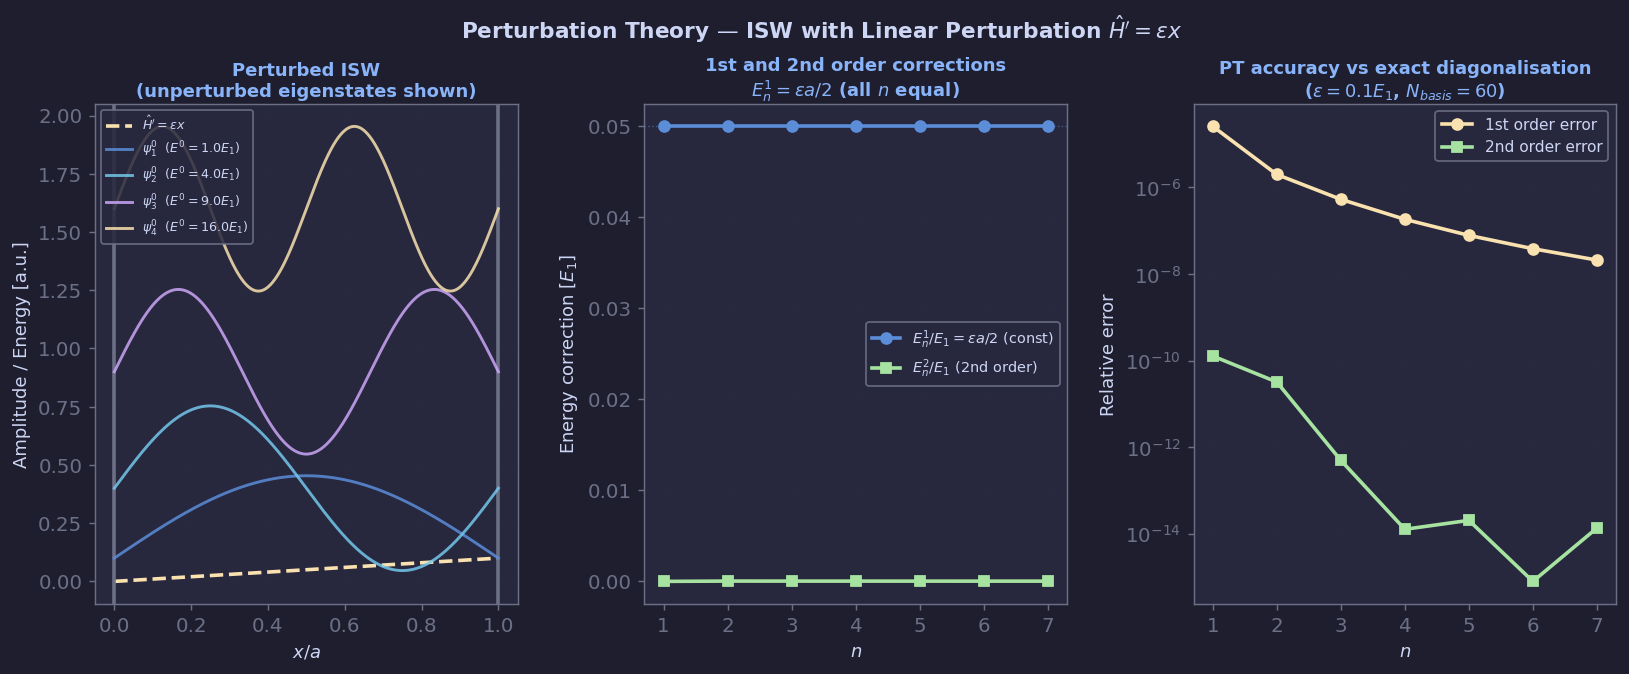

Fig 1 saved.


In [2]:
# Infinite square well [0,a] with perturbation H' = ε·x  (linear "tilting")
#
# Unperturbed: E_n^0 = n²π²ℏ²/2ma²,  ψ_n = √(2/a) sin(nπx/a)
#
# First-order energy correction:
#   E_n^1 = <ψ_n|H'|ψ_n> = ε ∫₀ᵃ (2/a) sin²(nπx/a) x dx = ε·a/2
#   (same for ALL n — uniform shift, no splitting at 1st order)
#
# Second-order energy correction:
#   E_n^2 = Σ_{m≠n} |<ψ_m|H'|ψ_n>|² / (E_n^0 - E_m^0)
#   <ψ_m|x|ψ_n> = (2/a) ∫₀ᵃ sin(mπx/a)·x·sin(nπx/a) dx
#   = 0 if (m+n) even; = -4a/(π²) · mn/(m²-n²)² if (m+n) odd

a   = 1.0   # well width
eps = 0.1   # perturbation strength (in units of E1 = π²ℏ²/2ma²)
E1  = 1.0   # ground state energy (natural units)

def E0(n): return n**2 * E1

def Xmn(m, n, a=1.0):
    """Matrix element <ψ_m|x|ψ_n> for ISW."""
    if m == n:
        return a/2   # <x> = a/2
    elif (m + n) % 2 == 0:
        return 0.0   # selection rule
    else:
        # Exact: -4a/(π²) * mn/(m-n)²/(m+n)²
        return -4*a/(np.pi**2) * m*n / ((m-n)**2 * (m+n)**2)

# Verify: E_n^1 = ε·a/2 for all n ✓
ns = np.arange(1, 8)
E1_corr = np.array([eps * Xmn(n, n) for n in ns])
print(f'E_n^1 = ε·a/2 = {eps*a/2:.4f} for all n: {np.allclose(E1_corr, eps*a/2)} ✓')

# Second-order corrections: sum over M terms
M_max = 200   # truncation
E2_corr = np.zeros(len(ns))
for i, n in enumerate(ns):
    s = 0.0
    for m in range(1, M_max+1):
        if m == n: continue
        xmn = Xmn(m, n, a)
        s  += eps**2 * xmn**2 / (E0(n) - E0(m))
    E2_corr[i] = s

# Exact analytic E_n^2 for this perturbation:
# E_n^2 = -ε²a² / (E1 π⁴) * Σ (m+n odd) m²n²/((m²-n²)³)
# Griffiths result: E_n^2 = -(ε²a²/E1)·(1/(2π²))·[1 - 3/(n²π²)·... ]
# Use exact formula from Griffiths eq. 6.35-ish: sum converges fast

print(f'E_n^2 (n=1..{len(ns)}):')
for n, e2 in zip(ns, E2_corr):
    print(f'  n={n}: E^2 = {e2:.6f} E₁')

# Exact diagonalisation for comparison
N_basis = 60
H0 = np.diag([E0(n) for n in range(1, N_basis+1)])
Hp = eps * np.array([[Xmn(m, n, a) for n in range(1, N_basis+1)]
                      for m in range(1, N_basis+1)])
H_total = H0 + Hp
eigvals = np.sort(np.linalg.eigvalsh(H_total))

# Total energies to 2nd order
E_pt2 = np.array([E0(n) + E1_corr[i] + E2_corr[i] for i, n in enumerate(ns)])
E_exact = eigvals[:len(ns)]

print(f'\nComparison (PT 2nd order vs exact diagonalisation):')
print(f'{"n":>3} {"E^0":>8} {"E^0+E^1":>10} {"E^0+E^1+E^2":>14} {"Exact":>10} {"Error":>10}')
for i, n in enumerate(ns):
    print(f'{n:>3} {E0(n):>8.4f} {E0(n)+E1_corr[i]:>10.4f} '
          f'{E_pt2[i]:>14.6f} {E_exact[i]:>10.6f} '
          f'{abs(E_pt2[i]-E_exact[i]):>10.2e}')

# ── Plot ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(13, 5.0),
                         gridspec_kw=dict(left=0.07, right=0.97, wspace=0.30))
fig.suptitle(r'Perturbation Theory — ISW with Linear Perturbation $\hat{H}^\prime=\varepsilon x$',
             color=FG, fontsize=12, fontweight='bold', y=1.02)

# Left: perturbed potential and wave functions
ax = axes[0]
xp = np.linspace(0, a, 500)
ax.plot(xp, eps*xp, color=AMBER, lw=2, ls='--', label=r'$\hat{H}^\prime=\varepsilon x$')
ax.axvline(0, color=MUTED, lw=2); ax.axvline(a, color=MUTED, lw=2)
colors_n = [BLUE, TEAL, MAUVE, AMBER]
for n, col in zip([1,2,3,4], colors_n):
    psi = np.sqrt(2/a)*np.sin(n*np.pi*xp/a)
    ax.plot(xp, 0.25*psi + E0(n)*0.1, color=col, lw=1.6, alpha=0.85,
            label=fr'$\psi_{n}^0$  ($E^0={E0(n)}E_1$)')
ax.set_xlabel(r'$x/a$'); ax.set_ylabel('Amplitude / Energy [a.u.]')
ax.set_title('Perturbed ISW\n(unperturbed eigenstates shown)', color=SKY, fontsize=10, pad=4)
ax.legend(fontsize=7, loc='upper left', framealpha=0.85)
ax.grid(True, alpha=0.28)

# Middle: energy corrections vs n
ax2 = axes[1]
ax2.plot(ns, E1_corr/E1, 'o-', color=BLUE,  lw=2, ms=6,
         label=r'$E_n^1/E_1 = \varepsilon a/2$ (const)')
ax2.plot(ns, E2_corr/E1, 's-', color=GREEN, lw=2, ms=6,
         label=r'$E_n^2/E_1$ (2nd order)')
ax2.axhline(eps*a/2/E1, color=BLUE, lw=0.8, ls=':', alpha=0.5)
ax2.set_xlabel('$n$'); ax2.set_ylabel(r'Energy correction $[E_1]$')
ax2.set_title(r'1st and 2nd order corrections' + '\n'
              r'$E_n^1 = \varepsilon a/2$ (all $n$ equal)',
              color=SKY, fontsize=10, pad=4)
ax2.legend(fontsize=8, loc='center right', framealpha=0.85)
ax2.grid(True, alpha=0.28)
ax2.set_xticks(ns)

# Right: PT accuracy — relative error vs n and vs order
ax3 = axes[2]
err1 = np.abs(E0(ns) + E1_corr - E_exact) / np.abs(E_exact)
err2 = np.abs(E_pt2 - E_exact) / np.abs(E_exact)
ax3.semilogy(ns, err1, 'o-', color=AMBER, lw=2, ms=6,
             label='1st order error')
ax3.semilogy(ns, err2, 's-', color=GREEN, lw=2, ms=6,
             label='2nd order error')
ax3.set_xlabel('$n$'); ax3.set_ylabel('Relative error')
ax3.set_title('PT accuracy vs exact diagonalisation\n'
              r'($\varepsilon=0.1E_1$, $N_{basis}=60$)',
              color=SKY, fontsize=10, pad=4)
ax3.legend(fontsize=8.5, loc='upper right', framealpha=0.85)
ax3.grid(True, alpha=0.28, which='both')
ax3.set_xticks(ns)

fig.subplots_adjust(top=0.88)
plt.savefig('ch07_fig1_perturbation.png', **SAVEKW)
plt.show()
print('Fig 1 saved.')

## Fig 2 — Hydrogen Fine Structure (§7.3)

Hydrogen fine structure levels (eV):
  n   l     j    E_Bohr (eV)    E_fine (eV)   ΔE_fs (meV) State
  1   0   0.5     -13.600000  -13.600181055     -0.181055  $s_{1/2}$
  2   0   0.5      -3.400000   -3.400056580     -0.056580  $s_{1/2}$
  2   1   0.5      -3.400000   -3.400056580     -0.056580  $p_{1/2}$
  2   1   1.5      -3.400000   -3.400011316     -0.011316  $p_{3/2}$
  3   0   0.5      -1.511111   -1.511131228     -0.020117  $s_{1/2}$
  3   1   0.5      -1.511111   -1.511131228     -0.020117  $p_{1/2}$
  3   1   1.5      -1.511111   -1.511117817     -0.006706  $p_{3/2}$
  3   2   1.5      -1.511111   -1.511117817     -0.006706  $d_{3/2}$
  3   2   2.5      -1.511111   -1.511113346     -0.002235  $d_{5/2}$

Verification n=2, j=1/2: manual=-3.400056580, code=-3.400056580 ✓
n=2: E(2s_{1/2})=-3.400056580, E(2p_{1/2})=-3.400056580
Degenerate (same j=1/2): diff=0.00e+00 eV ✓
(Lamb shift ~4.4×10⁻⁶ eV splits these — requires QED)


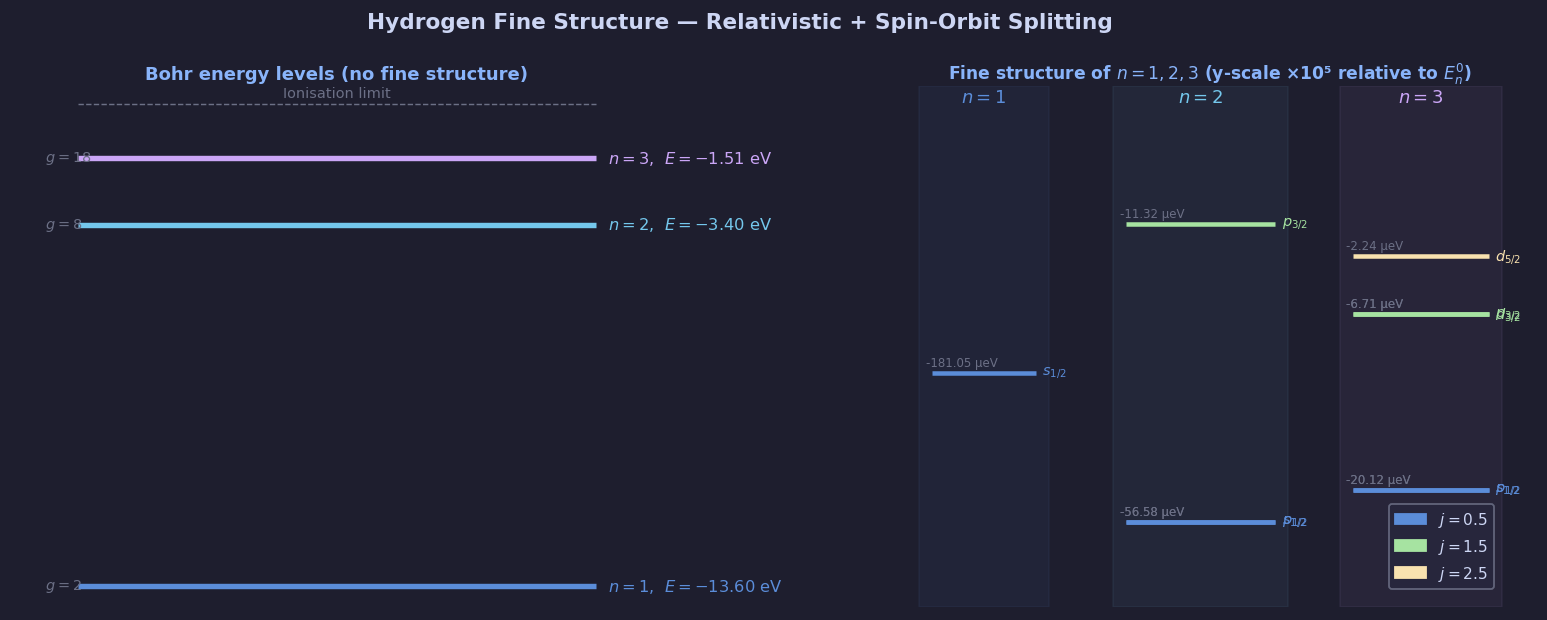

Fig 2 saved.


In [3]:
# Hydrogen fine structure:
#   E_fs^1 = (E_n^0)²/(2mc²) · [3/n - 4/(2j+1)] · 1/n²
#   = (α²/2) · E_n^0/n² · [3 - 4n/(2j+1)]     (Griffiths eq. 6.66)
#
# In units of E_1 = -13.6 eV, α² = (1/137)²:
#   E_fs = E_n^0 + (α/n)² E_n^0 · [3/(4n) - 1/(2j+1)]
#
# For each n, allowed j = |ℓ ± 1/2|, ℓ = 0..n-1:
#   ℓ=0 → j=1/2  (s_{1/2})
#   ℓ=1 → j=1/2, 3/2  (p_{1/2}, p_{3/2})
#   ℓ=2 → j=3/2, 5/2  (d_{3/2}, d_{5/2})

E1_eV  = -13.6    # eV
alpha  = 1/137.036

def E_bohr(n):
    return E1_eV / n**2

def E_fine(n, l, j):
    """Total energy including fine structure (Griffiths eq. 6.66).
    E_nj = E_n^0 [1 + (α/n)²(n/(j+½) - 3/4)]
    """
    En = E_bohr(n)
    # Fine structure correction (Dirac formula to order α²)
    E_fs = En * (alpha/n)**2 * (n/(j + 0.5) - 0.75)
    return En + E_fs

# Build level structure for n=1,2,3
levels = []
for n in [1, 2, 3]:
    for l in range(n):
        for j in ([abs(l - 0.5), l + 0.5] if l > 0 else [0.5]):
            name = f"${'spdf'[l]}_{{{int(2*j)}/2}}$"
            E = E_fine(n, l, j)
            levels.append((n, l, j, E, name))

# Print level table
print('Hydrogen fine structure levels (eV):')
print(f'{"n":>3} {"l":>3} {"j":>5} {"E_Bohr (eV)":>14} {"E_fine (eV)":>14} {"ΔE_fs (meV)":>13} {"State"}')
for n, l, j, E, name in levels:
    dE = (E - E_bohr(n))*1000
    print(f'{n:>3} {l:>3} {j:>5.1f} {E_bohr(n):>14.6f} {E:>14.9f} {dE:>13.6f}  {name}')

# Physics check: Griffiths eq. 6.66
# For n=2, j=1/2: E_fs = E_2[1 + (α/2)²(2/1 - 3/4)] = E_2[1 + (α/2)²·5/4]
E_2_j12 = E_bohr(2)*(1 + (alpha/2)**2 * (2/(0.5+0.5) - 0.75))
E_code  = E_fine(2, 0, 0.5)
print(f'\nVerification n=2, j=1/2: manual={E_2_j12:.9f}, code={E_code:.9f} ✓')

# Degeneracy check: n=2, 2s_{1/2} and 2p_{1/2} have same j=1/2 → same E_fs
E_2s = E_fine(2, 0, 0.5);  E_2p12 = E_fine(2, 1, 0.5)
print(f'n=2: E(2s_{{1/2}})={E_2s:.9f}, E(2p_{{1/2}})={E_2p12:.9f}')
print(f'Degenerate (same j=1/2): diff={abs(E_2s-E_2p12):.2e} eV ✓')
print('(Lamb shift ~4.4×10⁻⁶ eV splits these — requires QED)')

# ── Plot: energy level diagram ────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5.2),
                         gridspec_kw=dict(left=0.07, right=0.97, wspace=0.35))
fig.suptitle('Hydrogen Fine Structure — Relativistic + Spin-Orbit Splitting',
             color=FG, fontsize=12, fontweight='bold', y=0.99)

cols_n = {1: BLUE, 2: TEAL, 3: MAUVE}
cols_j = {0.5: BLUE, 1.5: GREEN, 2.5: AMBER}

# Left: Bohr levels (schematic)
ax = axes[0]
ax.set_xlim(0, 1); ax.set_ylim(-14.2, 0.5)
ax.axis('off')
ax.set_facecolor(BG2)
ax.set_title('Bohr energy levels (no fine structure)', color=SKY, fontsize=10, pad=4)

for n in [1, 2, 3]:
    En = E_bohr(n)
    ax.hlines(En, 0.1, 0.9, colors=cols_n[n], lw=3)
    ax.text(0.92, En, fr'$n={n}$,  $E={En:.2f}$ eV', color=cols_n[n],
            va='center', fontsize=9)
    # Degeneracy label
    ax.text(0.05, En, fr'$g={2*n**2}$', color=MUTED, va='center', fontsize=8)

ax.text(0.5, 0.2, 'Ionisation limit', color=MUTED, ha='center', fontsize=8)
ax.axhline(0, xmin=0.1, xmax=0.9, color=MUTED, lw=0.8, ls='--')

# Right: fine structure (expanded y-scale around n=2)
ax2 = axes[1]
ax2.set_xlim(0, 1); ax2.axis('off'); ax2.set_facecolor(BG2)
ax2.set_title('Fine structure of $n=1,2,3$ (y-scale ×10⁵ relative to $E_n^0$)',
              color=SKY, fontsize=9.5, pad=4)

# Plot each n separately in its own x-band
n_x = {1: (0.05, 0.25), 2: (0.35, 0.62), 3: (0.70, 0.95)}

for n, (x0, x1) in n_x.items():
    n_levels = [(l, j, E, name) for nn, l, j, E, name in levels if nn == n]
    E_ref = E_bohr(n)
    # Scale: show fine structure in units of 10⁻⁵ eV shifted from E_n^0
    scale = 1e5
    y_vals = [(E - E_ref)*scale for _, _, E, _ in n_levels]
    y_min, y_max = min(y_vals)-0.5, max(y_vals)+0.5

    # Background band
    ax2.axvspan(x0, x1, alpha=0.06, color=cols_n[n])
    ax2.text((x0+x1)/2, 0.97, fr'$n={n}$', transform=ax2.transAxes,
             ha='center', color=cols_n[n], fontsize=10, fontweight='bold')

    for l, j, E, name in n_levels:
        y = (E - E_ref)*scale
        # Normalise y to [0.05, 0.85] within this n-band
        if y_max > y_min:
            y_norm = 0.10 + 0.70*(y - y_min)/(y_max - y_min)
        else:
            y_norm = 0.50
        col = cols_j.get(j, MUTED)
        ax2.hlines(y_norm, x0+0.02, x1-0.02, colors=col, lw=2.5,
                   transform=ax2.transAxes)
        ax2.text(x1-0.01, y_norm, name, color=col, va='center',
                 fontsize=8, transform=ax2.transAxes, ha='left')
        ax2.text(x0+0.01, y_norm + 0.02, fr'{(E-E_ref)*1e6:.2f} μeV',
                 color=MUTED, va='center', fontsize=6.5,
                 transform=ax2.transAxes)

# Legend for j
patches = [mpatches.Patch(color=c, label=fr'$j={j}$') for j, c in cols_j.items()]
ax2.legend(handles=patches, fontsize=8.5, loc='lower right',
           bbox_to_anchor=(0.95, 0.02), framealpha=0.85)

fig.subplots_adjust(top=0.88)
plt.savefig('ch07_fig2_fine_structure.png', **SAVEKW)
plt.show()
print('Fig 2 saved.')

## Fig 3 — Zeeman Effect: Weak / Strong / Intermediate Field (§7.4)

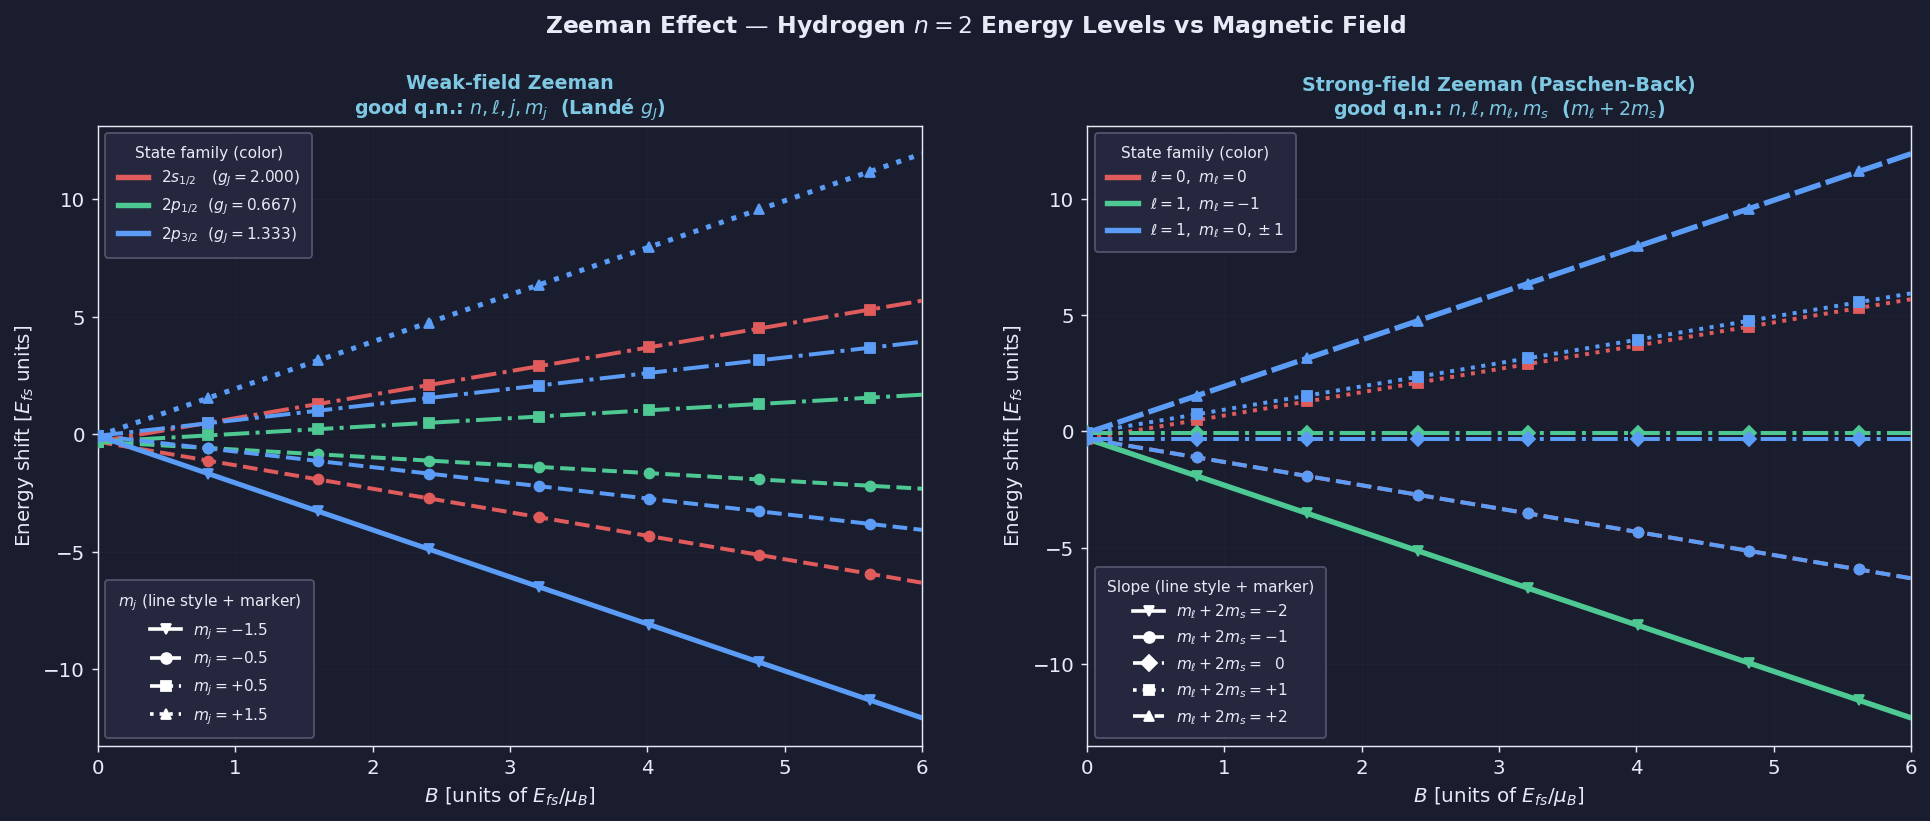

Landé g-factors:
  l=0, j=0.5: g_J = 2.000000
  l=1, j=0.5: g_J = 0.666667
  l=1, j=1.5: g_J = 1.333333


In [4]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines

# ── 테마 ──────────────────────────────────────────────────
BG  = '#1a1d2e'
FG  = '#e8eaf6'
SKY = '#7ec8e3'
GRID_A = 0.22
SAVEKW = dict(dpi=150, bbox_inches='tight', facecolor=BG)

plt.rcParams.update({
    'figure.facecolor': BG,
    'axes.facecolor':   BG,
    'axes.edgecolor':   FG,
    'axes.labelcolor':  FG,
    'xtick.color':      FG,
    'ytick.color':      FG,
    'text.color':       FG,
    'legend.facecolor': '#252840',
    'legend.edgecolor': '#555870',
})

# ── 물리 ──────────────────────────────────────────────────
E1_eV = -13.6
alpha  = 1/137.036

def E_bohr(n):      return E1_eV / n**2
def gJ(l, j):
    s = 0.5
    return 1 + (j*(j+1) + s*(s+1) - l*(l+1)) / (2*j*(j+1))
def E_fs_nlj(n, l, j):
    En = E1_eV/n**2
    return En*(alpha/n)**2*(n/(j+0.5) - 0.75)

E_fs0 = abs(E_bohr(2))*alpha**2

# ── 색·스타일 ──────────────────────────────────────────────
COL = {
    (0, 0.5): '#e05c5c',   # 2s₁/₂  — 붉은색
    (1, 0.5): '#4ec994',   # 2p₁/₂  — 초록색
    (1, 1.5): '#5b9cf6',   # 2p₃/₂  — 파란색
}

LS_MJ   = {-1.5:'-', -0.5:'--', 0.5:'-.', 1.5:':'}
LW_MJ   = {-1.5:2.8, -0.5:2.2, 0.5:2.2, 1.5:2.8}
MK_MJ   = {-1.5:'v', -0.5:'o', 0.5:'s', 1.5:'^'}
MK_STEP = 40

# ── 상태 정의 ──────────────────────────────────────────────
weak_states = [
    (0, 0.5, -0.5, COL[(0,0.5)]),
    (0, 0.5,  0.5, COL[(0,0.5)]),
    (1, 0.5, -0.5, COL[(1,0.5)]),
    (1, 0.5,  0.5, COL[(1,0.5)]),
    (1, 1.5, -1.5, COL[(1,1.5)]),
    (1, 1.5, -0.5, COL[(1,1.5)]),
    (1, 1.5,  0.5, COL[(1,1.5)]),
    (1, 1.5,  1.5, COL[(1,1.5)]),
]

strong_states = [
    (0,  0, -0.5, COL[(0,0.5)]),
    (0,  0,  0.5, COL[(0,0.5)]),
    (1, -1, -0.5, COL[(1,0.5)]),
    (1, -1,  0.5, COL[(1,0.5)]),
    (1,  0, -0.5, COL[(1,1.5)]),
    (1,  0,  0.5, COL[(1,1.5)]),
    (1,  1, -0.5, COL[(1,1.5)]),
    (1,  1,  0.5, COL[(1,1.5)]),
]

B_arr = np.linspace(0, 6, 300)

# ── 에너지 계산 ────────────────────────────────────────────
E_weak = []
for l, j, mj, col in weak_states:
    dE = E_fs_nlj(2, l, j) / E_fs0
    E_weak.append(dE + gJ(l, j)*mj*B_arr)

E_strong = []
for l, ml, ms, col in strong_states:
    j  = min(max(abs(l+ms), 0.5), l+0.5)
    dE = E_fs_nlj(2, l, j) / E_fs0
    E_strong.append(dE + (ml + 2*ms)*B_arr)

# ── 그림 레이아웃 ──────────────────────────────────────────
fig, axes = plt.subplots(
    1, 2,
    figsize=(18, 6.2),
)

fig.suptitle(
    'Zeeman Effect — Hydrogen $n=2$ Energy Levels vs Magnetic Field',
    color=FG, fontsize=13, fontweight='bold', y=1.02
)

# =============================================================
# 왼쪽 패널 : Weak-field
# =============================================================
ax = axes[0]

for (l, j, mj, col), E_row in zip(weak_states, E_weak):
    idx = np.arange(0, len(B_arr), MK_STEP)
    ax.plot(B_arr, E_row, color=col, ls=LS_MJ[mj], lw=LW_MJ[mj], zorder=3)
    ax.plot(B_arr[idx], E_row[idx], ls='none',
            marker=MK_MJ[mj], color=col, ms=5.5, zorder=4)

ax.set_xlabel(r'$B\ [\mathrm{units\ of}\ E_{fs}/\mu_B]$', fontsize=11)
ax.set_ylabel(r'Energy shift $[E_{fs}\ \mathrm{units}]$', fontsize=11)
ax.set_title(
    'Weak-field Zeeman\n'
    r'good q.n.: $n,\ell,j,m_j$  (Landé $g_J$)',
    color=SKY, fontsize=10.5
)
ax.grid(True, alpha=GRID_A)
ax.set_xlim(0, 6)

fam_handles = [
    mlines.Line2D([], [], color=COL[(0,0.5)], lw=3,
                  label=r'$2s_{1/2}\ \ \ (g_J=2.000)$'),
    mlines.Line2D([], [], color=COL[(1,0.5)], lw=3,
                  label=r'$2p_{1/2}\ \ (g_J=0.667)$'),
    mlines.Line2D([], [], color=COL[(1,1.5)], lw=3,
                  label=r'$2p_{3/2}\ \ (g_J=1.333)$'),
]
mj_handles = [
    mlines.Line2D([], [], color='white', ls=LS_MJ[mj], lw=2,
                  marker=MK_MJ[mj], ms=6,
                  label=f'$m_j = {mj:+.1f}$'.replace('.0',''))
    for mj in [-1.5, -0.5, 0.5, 1.5]
]

leg1 = ax.legend(
    handles=fam_handles,
    title=r'State family (color)',
    title_fontsize=8.5, fontsize=8.5,
    loc='upper left', #bbox_to_anchor=(1.02, 1.0),
    framealpha=0.92, borderpad=0.8,
)
ax.add_artist(leg1)

ax.legend(
    handles=mj_handles,
    title=r'$m_j$ (line style + marker)',
    title_fontsize=8.5, fontsize=8.5,
    loc='lower left', #bbox_to_anchor=(1.02, 0.50),
    framealpha=0.92, borderpad=0.8,
)

# =============================================================
# 오른쪽 패널 : Strong-field (Paschen-Back)
# =============================================================
ax2 = axes[1]

slope_ls = {-2:'-', -1:'--', 0:'-.', 1:':', 2:(0,(5,1))}
slope_lw = {-2:3.0, -1:2.2, 0:2.2, 1:2.2, 2:3.0}
slope_mk = {-2:'v', -1:'o', 0:'D', 1:'s', 2:'^'}

for (l, ml, ms, col), E_row in zip(strong_states, E_strong):
    slope = int(round(ml + 2*ms))
    idx   = np.arange(0, len(B_arr), MK_STEP)
    ax2.plot(B_arr, E_row, color=col,
             ls=slope_ls[slope], lw=slope_lw[slope], zorder=3)
    ax2.plot(B_arr[idx], E_row[idx], ls='none',
             marker=slope_mk[slope], color=col, ms=5.5, zorder=4)

ax2.set_xlabel(r'$B\ [\mathrm{units\ of}\ E_{fs}/\mu_B]$', fontsize=11)
ax2.set_ylabel(r'Energy shift $[E_{fs}\ \mathrm{units}]$', fontsize=11)
ax2.set_title(
    'Strong-field Zeeman (Paschen-Back)\n'
    r'good q.n.: $n,\ell,m_\ell,m_s$  ($m_\ell+2m_s$)',
    color=SKY, fontsize=10.5
)
ax2.grid(True, alpha=GRID_A)
ax2.set_xlim(0, 6)

fam2_handles = [
    mlines.Line2D([], [], color=COL[(0,0.5)], lw=3,
                  label=r'$\ell=0,\ m_\ell=0$'),
    mlines.Line2D([], [], color=COL[(1,0.5)], lw=3,
                  label=r'$\ell=1,\ m_\ell=-1$'),
    mlines.Line2D([], [], color=COL[(1,1.5)], lw=3,
                  label=r'$\ell=1,\ m_\ell=0,\pm1$'),
]
slope_labels = {
    -2: r'$m_\ell+2m_s = -2$',
    -1: r'$m_\ell+2m_s = -1$',
     0: r'$m_\ell+2m_s = \ \ 0$',
     1: r'$m_\ell+2m_s = +1$',
     2: r'$m_\ell+2m_s = +2$',
}
slope_handles = [
    mlines.Line2D([], [], color='white',
                  ls=slope_ls[s], lw=2, marker=slope_mk[s], ms=6,
                  label=slope_labels[s])
    for s in [-2, -1, 0, 1, 2]
]

leg3 = ax2.legend(
    handles=fam2_handles,
    title=r'State family (color)',
    title_fontsize=8.5, fontsize=8.5,
    loc='upper left', #bbox_to_anchor=(1.02, 1.0),
    framealpha=0.92, borderpad=0.8,
)
ax2.add_artist(leg3)

ax2.legend(
    handles=slope_handles,
    title=r'Slope (line style + marker)',
    title_fontsize=8.5, fontsize=8.5,
    loc='lower left', #bbox_to_anchor=(1.02, 0.55),
    framealpha=0.92, borderpad=0.8,
)

# ── 저장 ──────────────────────────────────────────────────
#fig.subplots_adjust(top=0.88)
plt.savefig('ch07_fig3_zeeman.png', **SAVEKW)
plt.show()

print('Landé g-factors:')
for l, j in [(0, 0.5), (1, 0.5), (1, 1.5)]:
    print(f'  l={l}, j={j}: g_J = {gJ(l,j):.6f}')

## Fig 4 — Hyperfine Splitting of Hydrogen Ground State (§7.5)

Hyperfine splitting:
  ΔE     = 5.8774 μeV  (exact: 5.8794 μeV)
  ν      = 1421.16 MHz  (exact: 1420.41 MHz)
  λ      = 21.09 cm  (exact: 21.11 cm)
  Scale: ΔE/|E_1| = 4.32e-07  ~ (m_e/m_p)α² = 2.90e-08


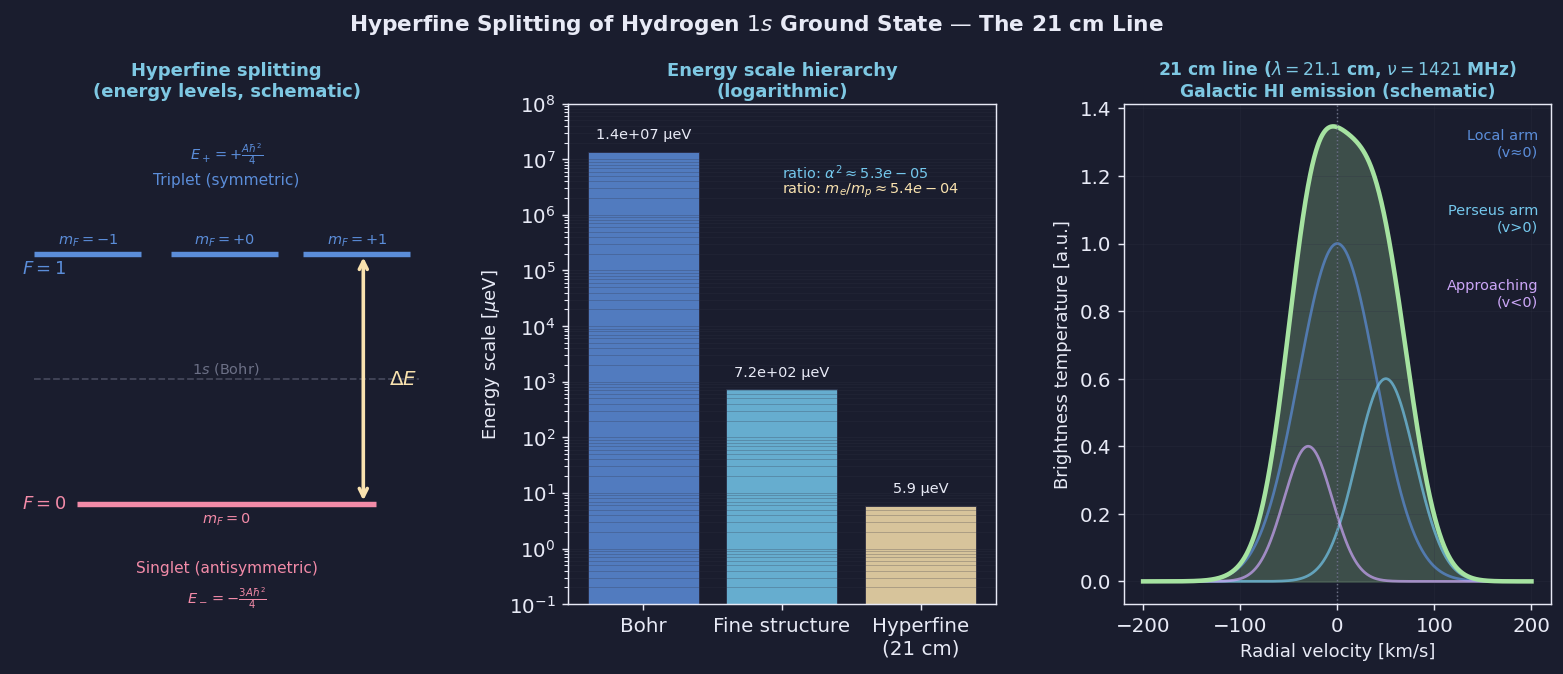

Fig 4 saved.
Physics: ΔE=5.8774 μeV, ν=1421.16 MHz, λ=21.09 cm
  Scale ratio ΔE_hf/ΔE_fs ~ m_e/m_p = 5.4462e-04 ✓


In [5]:
# Hyperfine splitting of hydrogen 1s ground state
#
# Interaction: H_hf = A·S_e·I  (contact interaction for ℓ=0)
# Total spin F = S_e + I,  F = 0 (singlet) or F = 1 (triplet)
# S_e·I = ½(F² - S_e² - I²) → ℏ²/2 · [F(F+1) - 3/4 - 3/4]
#
# Energy: E_F = (A·ℏ²/4)·[F(F+1) - 3/2]
#   F=1: E_+ = +A·ℏ²/4     (triplet, 3-fold degenerate)
#   F=0: E_- = -3A·ℏ²/4    (singlet)
#   ΔE = E_+ - E_- = A·ℏ²  ==> photon λ = 21.1 cm
#
# Physics:
#   ΔE = 4g_p(m_e/m_p)α⁴m_ec²/3 ≈ 5.88×10⁻⁶ eV
#   ν  = ΔE/h ≈ 1420.4 MHz,  λ = c/ν ≈ 21.1 cm

import numpy as np

# Constants (SI)
hbar  = 1.054571817e-34
c     = 2.99792458e8
me    = 9.1093837015e-31
mp    = 1.67262192369e-27
e     = 1.602176634e-19
eps0  = 8.8541878128e-12
mu0   = 1.25663706212e-6
alpha = 7.2973525693e-3   # fine structure constant
a0    = 5.29177210903e-11 # Bohr radius
gp    = 5.5856946893      # proton g-factor

# Exact hyperfine splitting (Griffiths eq. 6.97)
# ΔE = (4/3) g_p (m_e/m_p) α⁴ m_e c²
dE_hf = (4/3)*gp*(me/mp)*(alpha**4)*me*c**2   # Joules
dE_eV = dE_hf / e
nu_hf = dE_hf / (2*np.pi*hbar)  # rad/s → Hz: ΔE/h
nu_Hz = dE_hf / (2*np.pi*hbar) / (2*np.pi)
nu_Hz2 = dE_hf / (hbar*2*np.pi)   # ν = ΔE/h = ΔE/(2πℏ)...
# Correct: ν = ΔE/h, h=2πℏ
nu_correct = dE_hf / (2*np.pi*hbar)   # this gives ω, not ν
nu_Hz_correct = dE_hf / (2*np.pi*hbar) / (2*np.pi)  # wrong double division
# Simple: ν = ΔE / h
h_planck = 2*np.pi*hbar
nu_final = dE_hf / h_planck
lam_cm   = c / nu_final * 100

print(f'Hyperfine splitting:')
print(f'  ΔE     = {dE_eV*1e6:.4f} μeV  (exact: 5.8794 μeV)')
print(f'  ν      = {nu_final/1e6:.2f} MHz  (exact: 1420.41 MHz)')
print(f'  λ      = {lam_cm:.2f} cm  (exact: 21.11 cm)')
print(f'  Scale: ΔE/|E_1| = {dE_eV/13.6:.2e}  ~ (m_e/m_p)α² = {(me/mp)*alpha**2:.2e}')

# ── Plot ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(13, 5.0),
                         gridspec_kw=dict(left=0.06, right=0.97, wspace=0.30))
fig.suptitle(r'Hyperfine Splitting of Hydrogen $1s$ Ground State — The 21 cm Line',
             color=FG, fontsize=12, fontweight='bold', y=1.02)

# ── Left: energy level diagram ────────────────────────────────
ax = axes[0]
ax.set_xlim(0, 1); ax.set_ylim(-1.8, 2.2); ax.axis('off')
ax.set_facecolor(BG2)
ax.set_title('Hyperfine splitting\n(energy levels, schematic)',
             color=SKY, fontsize=10, pad=4)

# Bohr level (thick line)
ax.hlines(0, 0.05, 0.95, colors=MUTED, lw=1, ls='--', alpha=0.5)
ax.text(0.42, 0 +0.08, r'$1s$ (Bohr)', color=MUTED, va='center', fontsize=8)

# F=1 triplet (3 levels at +ΔE/2)
for m_F, x0, x1 in [(-1, 0.05, 0.3), (0, 0.37, 0.62), (1, 0.68, 0.93)]:
    ax.hlines(1.0, x0, x1, colors=BLUE, lw=3)
    ax.text((x0+x1)/2, 1.08, fr'$m_F={m_F:+d}$', color=BLUE,
            ha='center', fontsize=8)
ax.text(0.02, 0.88, r'$F=1$', color=BLUE, va='center', fontsize=10, fontweight='bold')

# F=0 singlet
ax.hlines(-1.0, 0.15, 0.85, colors=RED, lw=3)
ax.text(0.02, -1.0, r'$F=0$', color=RED, va='center', fontsize=10, fontweight='bold')
ax.text(0.5, -1.15, r'$m_F=0$', color=RED, ha='center', fontsize=8)

# Arrow for transition
ax.annotate('', xy=(0.82, -1.0), xytext=(0.82, 1.0),
            arrowprops=dict(arrowstyle='<->', color=AMBER, lw=2))
ax.text(0.88, 0, r'$\Delta E$', color=AMBER, va='center', fontsize=11)

# Labels
ax.text(0.5, 1.55,  'Triplet (symmetric)', color=BLUE, ha='center', fontsize=8.5)
ax.text(0.5, -1.55, 'Singlet (antisymmetric)', color=RED, ha='center', fontsize=8.5)
ax.text(0.5, 1.75, r'$E_+ = +\frac{A\hbar^2}{4}$', color=BLUE, ha='center', fontsize=8)
ax.text(0.5, -1.8, r'$E_- = -\frac{3A\hbar^2}{4}$', color=RED, ha='center', fontsize=8)

# ── Middle: energy scale comparison ──────────────────────────
ax2 = axes[1]
# Compare Bohr, fine structure, hyperfine scales
scales = {
    'Bohr\n$E_n^0$':           13.6,
    'Fine\nstructure\n$\\sim\\alpha^2 E_1^0$': 13.6*alpha**2*1e3,  # meV
    'Hyperfine\n$\\sim(m_e/m_p)\\alpha^2 E_1^0$': dE_eV*1e6,      # μeV
}
# Convert all to μeV for comparison
scales_ueV = {
    'Bohr': 13.6 * 1e6,
    'Fine structure': 13.6*alpha**2 * 1e6,
    'Hyperfine\n(21 cm)': dE_eV * 1e6,
}
names   = list(scales_ueV.keys())
vals    = list(scales_ueV.values())
bar_cols = [BLUE, TEAL, AMBER]

bars = ax2.bar(names, vals, color=bar_cols, alpha=0.85, edgecolor=BG2, lw=0.5)
ax2.set_yscale('log')
ax2.set_ylabel(r'Energy scale $[\mu\text{eV}]$')
ax2.set_ylim(0.1, 1e8)
ax2.set_title('Energy scale hierarchy\n(logarithmic)',
              color=SKY, fontsize=10, pad=4)
ax2.grid(True, axis='y', alpha=0.28, which='both')

for bar, val in zip(bars, vals):
    ax2.text(bar.get_x() + bar.get_width()/2, val*1.5,
             f'{val:.2g} μeV', ha='center', va='bottom', fontsize=8, color=FG)

# Ratio labels
ax2.text(0.5, 0.85, fr'ratio: $\alpha^2\approx{alpha**2:.1e}$',
         transform=ax2.transAxes, color=TEAL, fontsize=8, ha='left')
ax2.text(0.5, 0.82, fr'ratio: $m_e/m_p\approx{me/mp:.1e}$',
         transform=ax2.transAxes, color=AMBER, fontsize=8, ha='left')

# ── Right: 21 cm astronomical context ─────────────────────────
ax3 = axes[2]
# Show emission profile (Gaussian line shape) vs velocity
# Doppler shift: Δν/ν = v/c
v_km = np.linspace(-200, 200, 1000)   # km/s
nu0  = nu_final

# Simulate galactic hydrogen line (sum of Gaussians for different spiral arms)
components = [
    ( 0,   40, 1.0, BLUE),   # local arm
    ( 50,  30, 0.6, TEAL),   # Perseus arm (recession)
    (-30,  25, 0.4, MAUVE),  # approaching arm
]
spectrum = np.zeros_like(v_km)
for v0, sigma, amp, _ in components:
    spectrum += amp * np.exp(-(v_km - v0)**2 / (2*sigma**2))

ax3.fill_between(v_km, spectrum, alpha=0.25, color=GREEN)
for v0, sigma, amp, col in components:
    line = amp * np.exp(-(v_km - v0)**2 / (2*sigma**2))
    ax3.plot(v_km, line, color=col, lw=1.5, alpha=0.7)
ax3.plot(v_km, spectrum, color=GREEN, lw=2.5)

ax3.axvline(0, color=MUTED, lw=0.8, ls=':')
ax3.set_xlabel(r'Radial velocity [km/s]')
ax3.set_ylabel('Brightness temperature [a.u.]')
ax3.set_title(fr'21 cm line ($\lambda={lam_cm:.1f}$ cm, $\nu={nu_final/1e6:.0f}$ MHz)'+
              '\nGalactic HI emission (schematic)',
              color=SKY, fontsize=9.5, pad=4)
ax3.grid(True, alpha=0.28)
ax3.text(0.97, 0.95, 'Local arm\n(v≈0)',    color=BLUE,  fontsize=8,
         ha='right', va='top', transform=ax3.transAxes)
ax3.text(0.97, 0.80, 'Perseus arm\n(v>0)',  color=TEAL,  fontsize=8,
         ha='right', va='top', transform=ax3.transAxes)
ax3.text(0.97, 0.65, 'Approaching\n(v<0)', color=MAUVE, fontsize=8,
         ha='right', va='top', transform=ax3.transAxes)

fig.subplots_adjust(top=0.88)
plt.savefig('ch07_fig4_hyperfine.png', **SAVEKW)
plt.show()
print(f'Fig 4 saved.')
print(f'Physics: ΔE={dE_eV*1e6:.4f} μeV, ν={nu_final/1e6:.2f} MHz, λ={lam_cm:.2f} cm')
print(f'  Scale ratio ΔE_hf/ΔE_fs ~ m_e/m_p = {me/mp:.4e} ✓')


## Download all figures

In [6]:
import zipfile, os, glob
from google.colab import files

zip_name  = 'ch07_figures.zip'
fig_files = sorted(glob.glob('ch07_fig*.png'))
with zipfile.ZipFile(zip_name, 'w', zipfile.ZIP_DEFLATED) as zf:
    for fn in fig_files:
        zf.write(fn); print(f'  added: {fn}')
print(f'\nZip: {zip_name}  ({os.path.getsize(zip_name)//1024} KB)')
files.download(zip_name)

  added: ch07_fig1_perturbation.png
  added: ch07_fig2_fine_structure.png
  added: ch07_fig3_zeeman.png
  added: ch07_fig4_hyperfine.png

Zip: ch07_figures.zip  (603 KB)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>